# Figure SX | Poor alignment of the midline and interlaminar nuclei

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc

import sys
sys.path.append('/code/')
from thalamus_merfish_analysis import abc_load as abc
from thalamus_merfish_analysis import ccf_images as cimg
from thalamus_merfish_analysis import ccf_erode as cerode
from thalamus_merfish_analysis import ccf_plots as cplots

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from matplotlib import rcParams
rcParams['ps.fonttype'] = 42
rcParams['pdf.fonttype'] = 42
rcParams['font.size'] = 7

import colorcet as cc

import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline') 

In [3]:
results_dir = '../../results'

## Load thalamus data

In [4]:
# Load the full thalamus anndata object
obs_th = abc.load_standard_thalamus(data_structure='obs')

# Subset to just the left hemisphere
obs_th_left = obs_th[obs_th['left_hemisphere']].copy()

In [5]:
# set spatial column names to `_reconstructed` coordinate space
coords = '_reconstructed'

x_col = 'x'+coords
y_col = 'y'+coords
section_col = z_col = 'z'+coords

In [6]:
# Load the CCF structures image
ccf_images = abc.get_ccf_labels_image()

# Merge substructures into structures (esp. AMd + AMv -> AM; LGd-co + LGd-ip + LGd-sh -> LG)
ccf_images = cerode.merge_substructures(ccf_images, ccf_level='structure')

# Precompute boundaries to use multiple times in this notebook w/o need to recompute
# we only need to load the boundaries for sections that contain the thalamus
sections_all = sorted(obs_th[section_col].unique())
sections_int = np.rint(np.array(sections_all)/0.2).astype(int)

# precompute boundaries for thalamic sections
ccf_boundaries = cimg.sectionwise_label_erosion(ccf_images, distance_px=1, 
                                                fill_val=0, return_edges=True, 
                                                section_list=sections_int
                                                )

In [8]:
# Load the CCF structures image - just the left hemisphere
ccf_images_left = abc.get_ccf_labels_image(subset_to_left_hemi=True)

# Merge substructures into structures (esp. AMd + AMv -> AM; LGd-co + LGd-ip + LGd-sh -> LG)
ccf_images_left = cerode.merge_substructures(ccf_images_left, ccf_level='structure')

# Precompute boundaries to use multiple times in this notebook w/o need to recompute
# we only need to load the boundaries for sections that contain the thalamus
sections_all = sorted(obs_th_left[section_col].unique())
sections_int = np.rint(np.array(sections_all)/0.2).astype(int)

# precompute boundaries for thalamic sections
ccf_boundaries_left = cimg.sectionwise_label_erosion(ccf_images_left, distance_px=1, 
                                                fill_val=0, return_edges=True, 
                                                section_list=sections_int
                                                )

In [9]:
# if you reload thalamus_merfish_analysis.ccf_plots after this cell has been run, 
# cplots.CCF_REGIONS_DEFAULT will be reset to None & you'll need to re-run this cell
cplots.CCF_REGIONS_DEFAULT = abc.get_thalamus_names()

In [10]:
# load the published color palettes for the ABC Atlas taxonomy
abc_palettes = {level: abc.get_taxonomy_palette(level) for level in 
                ['neurotransmitter','class', 'subclass','supertype','cluster']}

# We have also provided a secondary color palette for the cluster level that 
# attempts to increase the color contrast between spatially negihboring clusters
# TODO: once released as package, this won't be accessible through a hardcode
palette_df = pd.read_csv('/code/thalamus_merfish_analysis/resources/cluster_palette_glasbey.csv')
abc_palettes['cluster'] = dict(zip(palette_df['Unnamed: 0'], palette_df['0']))

## Load data for just the Somatosensory cells

In [35]:
# want to highlight some midline and interlaminar nuclei
nuclei_mid_interlam = ['IMD'] #['IAD', 'IMD', 'PCN']
sections_mid_interlam = [6.6, 6.8, 7.0, 7.2, 7.6, 7.8, 8.0]
taxonomy_level = 'subclass'

In [36]:
obs_plot = obs_th_left.copy()

# get just the cells from subclass 150 and 151
obs_plot = obs_plot[obs_plot[taxonomy_level].str.contains('150|151', regex=True)]
obs_plot.loc[:,taxonomy_level] = obs_plot.loc[:,taxonomy_level].cat.remove_unused_categories()

## Fig. X? | Somatosensory subclasses

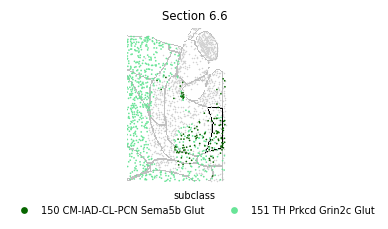

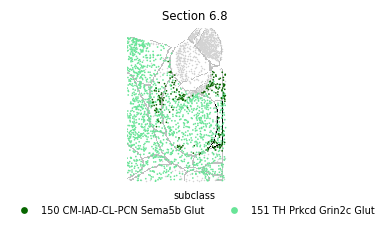

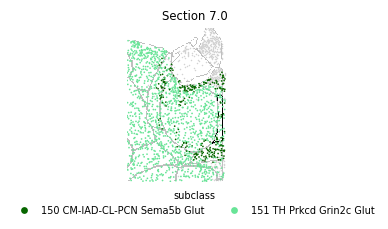

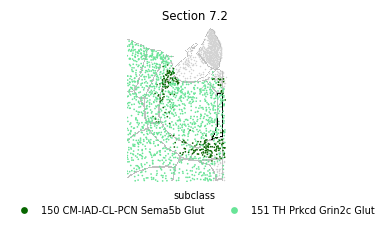

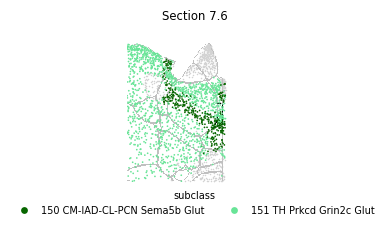

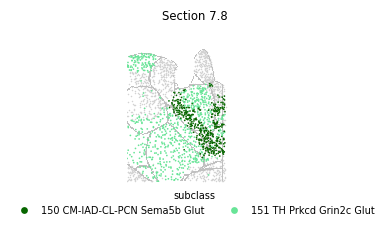

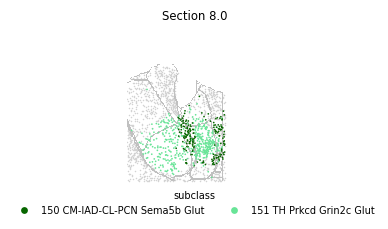

In [37]:
# set kwargs fpr annotated cluster plots
kwargs_cluster_annotations = dict(
    section_col=z_col,
    x_col=x_col,
    y_col=y_col,
    point_size=1.5,
    figsize=(4, 2),
    face_palette=None,
    edge_color='silver',
    custom_xy_lims=[4.25,6, 6.25,4.25]
    )

# get the cluster annotations for the nucleus of interest
# nucleus = nuclei_mid_interlam
sections_to_plot = sections_mid_interlam # None
nuclei_highlight = nuclei_mid_interlam

plt.rcParams.update({'font.size': 7})
figs_annot = cplots.plot_ccf_overlay(obs_plot, 
                                    ccf_images_left,
                                    boundary_img=ccf_boundaries_left,
                                    bg_cells=obs_th_left, 
                                    ccf_highlight=nuclei_highlight,
                                    point_hue=taxonomy_level, 
                                    sections=sections_to_plot,
                                    point_palette=abc_palettes[taxonomy_level],
                                    legend='cells',
                                    # show_axes=True,
                                    **kwargs_cluster_annotations)

for i, sec in enumerate(sections_to_plot):
    figs_annot[i].savefig(f'{results_dir}/figSX_{taxonomy_level}_150_151_z{sec}_midline_interlam.pdf', 
                          transparent=True, bbox_inches='tight')
    figs_annot[i].savefig(f'{results_dir}/figSX_{taxonomy_level}_150_151_z{sec}_midline_interlam.png', 
                          transparent=True, bbox_inches='tight', dpi=1200)

## Fig. X? | Somatosensory supertypes

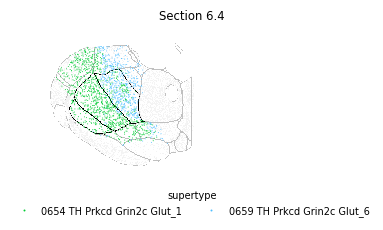

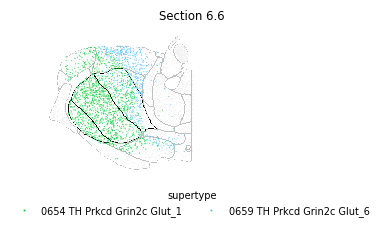

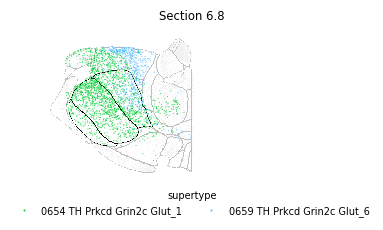

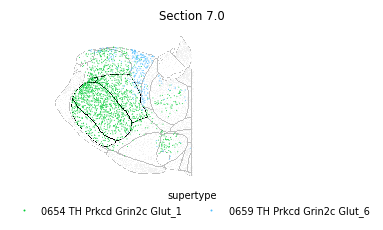

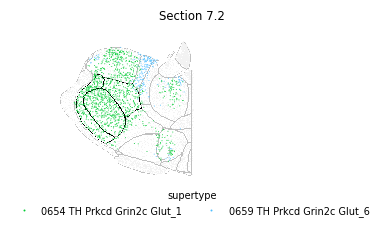

In [13]:
# set kwargs fpr annotated cluster plots
kwargs_cluster_annotations = dict(
    section_col=z_col,
    x_col=x_col,
    y_col=y_col,
    point_size=0.5,
    figsize=(4, 2),
    face_palette=None,
    edge_color='silver'
    )

# get the cluster annotations for the nucleus of interest
nucleus = nuclei_somatosensory
sections_to_plot = sections_somatosensory
nuclei_highlight = nuclei_somatosensory
taxonomy_level = 'supertype'
obs_annot = abc.get_obs_from_annotations(nucleus, 
                                         obs_th_left, 
                                         taxonomy_level=taxonomy_level,
                                         include_shared_clusters=True)

plt.rcParams.update({'font.size': 7})
figs_annot = cplots.plot_ccf_overlay(obs_annot, 
                                    ccf_images_left,
                                    boundary_img=ccf_boundaries_left,
                                    bg_cells=obs_th_left, 
                                    ccf_highlight=nuclei_highlight,
                                    point_hue=taxonomy_level, 
                                    sections=sections_to_plot,
                                    point_palette=abc_palettes[taxonomy_level],
                                    legend='cells',
                                    **kwargs_cluster_annotations)
for i, sec in enumerate(sections_to_plot):
    figs_annot[i].savefig(f'{results_dir}/figX_supertype_annotations_z{sec}_somatosensory.pdf', 
                          transparent=True, bbox_inches='tight')
    figs_annot[i].savefig(f'{results_dir}/figX_supertype_annotations_z{sec}_somatosensory.png', 
                          transparent=True, bbox_inches='tight', dpi=1200)

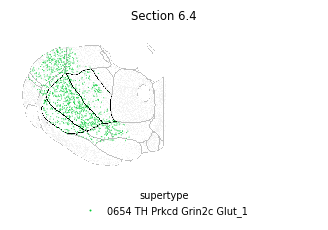

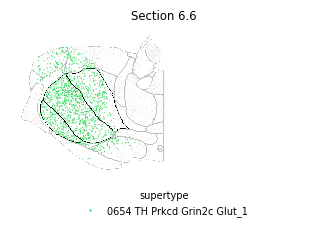

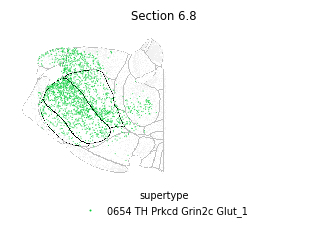

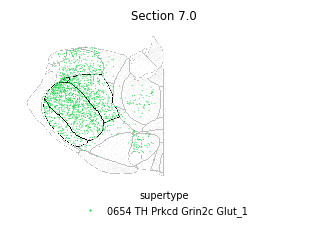

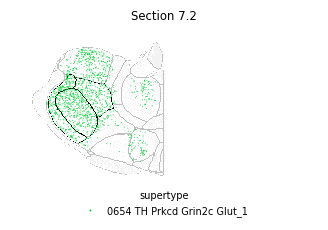

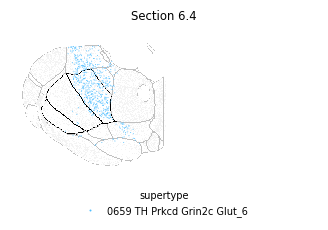

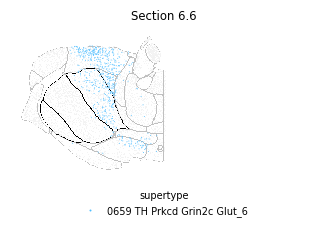

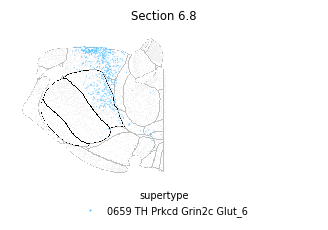

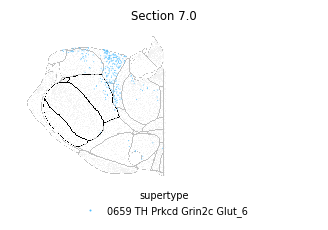

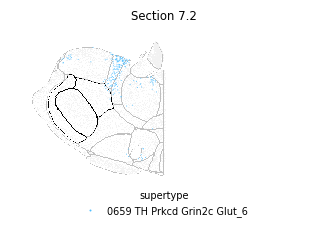

In [14]:
unique_supertypes = obs_annot['supertype'].unique()
for st in unique_supertypes:
    obs_annot_st = obs_annot[obs_annot['supertype']==st]
    plt.rcParams.update({'font.size': 7})
    figs_annot = cplots.plot_ccf_overlay(obs_annot_st, 
                                        ccf_images_left,
                                        boundary_img=ccf_boundaries_left,
                                        bg_cells=obs_th_left, 
                                        ccf_highlight=nuclei_highlight,
                                        point_hue=taxonomy_level, 
                                        sections=sections_to_plot,
                                        point_palette=abc_palettes[taxonomy_level],
                                        legend='cells',
                                        **kwargs_cluster_annotations)
    for i, sec in enumerate(sections_to_plot):
        figs_annot[i].savefig(f'{results_dir}/figX_supertype_{st[:4]}_annotations_z{sec}_somatosensory.pdf', 
                            transparent=True, bbox_inches='tight')
        figs_annot[i].savefig(f'{results_dir}/figX_supertype_{st[:4]}_annotations_z{sec}_somatosensory.png', 
                            transparent=True, bbox_inches='tight', dpi=1200)

## Fig. 3C | Dotplot of differentially expressed genes (DEGs) in the 3 ATN supertypes

### Fig. S2 | Exploratory DEG dotplot (5 genes per supertype)

In [15]:
supertypes_annot_all = adata_annot.obs['supertype'].cat.categories
display(supertypes_annot_all.to_list())

['0654 TH Prkcd Grin2c Glut_1', '0659 TH Prkcd Grin2c Glut_6']

In [16]:
supertypes_annot = [
    '0654 TH Prkcd Grin2c Glut_1', 
    '0659 TH Prkcd Grin2c Glut_6',
]

0654 TH Prkcd Grin2c Glut_1


0659 TH Prkcd Grin2c Glut_6
['Scn4b', 'Kcnab3', 'Rgs4', 'Rorb', 'Pvalb', 'Gpr4', 'Tcf7l2', 'St6galnac5', 'Calb1', 'Tnc']


/opt/conda/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


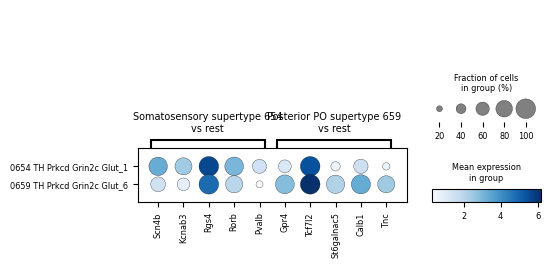

In [27]:
deg_list_somatosensory_st = []

for st in supertypes_annot:
  print(st)
  sc.tl.rank_genes_groups(adata_annot, groupby="supertype", groups=[st],
                          reference='rest', n_genes=5, method="wilcoxon")
  deg_list_somatosensory_st.extend(sc.get.rank_genes_groups_df(adata_annot, group=st).names.to_list())

print(deg_list_somatosensory_st)

# manually set gene group labels for dotplot
var_group_positions_st = [
  [0,4], 
  [5,9], 
]
var_group_labels_st = [
  'Somatosensory supertype 654\nvs rest', 
  'Posterior PO supertype 659\nvs rest',
]
# dotplot
dotplot_st_explore = sc.pl.dotplot(adata_annot,
                                  deg_list_somatosensory_st,
                                #   sorted(list(set(deg_list_ATN))), 
                                  groupby='supertype', 
                                  dendrogram=False,
                                  cmap='Blues',
                                  var_group_positions=var_group_positions_st,
                                  var_group_labels=var_group_labels_st,
                                  var_group_rotation=0,
                                  # return_fig=True
                                  )

In [19]:
deg_list_somatosensory_st_manual = [
    'Scn4b', 'Kcnab3', 'Pvalb', # 0654
    'Gpr4', 'St6galnac5', 'Calb1', 'Tnc', # 0659
]

/opt/conda/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


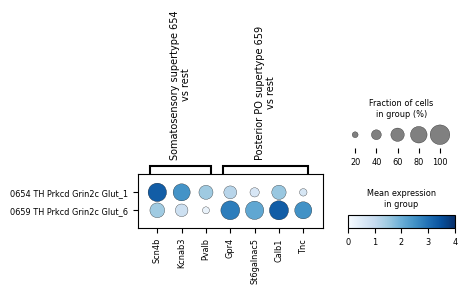

In [28]:
# manually set gene group labels for dotplot
var_group_positions_st = [
  [0,2], 
  [3,6], 
]
var_group_labels_st = [
  'Somatosensory supertype 654\nvs rest', 
  'Posterior PO supertype 659\nvs rest',
]

# dotplot
dotplot_st_curated = sc.pl.dotplot(adata_annot,
                                  deg_list_somatosensory_st_manual,
                                  groupby='supertype', 
                                  dendrogram=False,
                                  cmap='Blues',
                                  vmin=0,
                                  vmax=4,
                                  var_group_positions=var_group_positions_st,
                                  var_group_labels=var_group_labels_st,
                                  var_group_rotation=90,
                                  return_fig=True)

# save
dotplot_st_curated.savefig(f'{results_dir}/figX_degs_somatosensory_{taxonomy_level}_vs_rest_dotplot_curated.pdf', 
                          transparent=True, bbox_inches='tight')

## Fig. 3B | Gene expression of supertype DEGs in the ATN

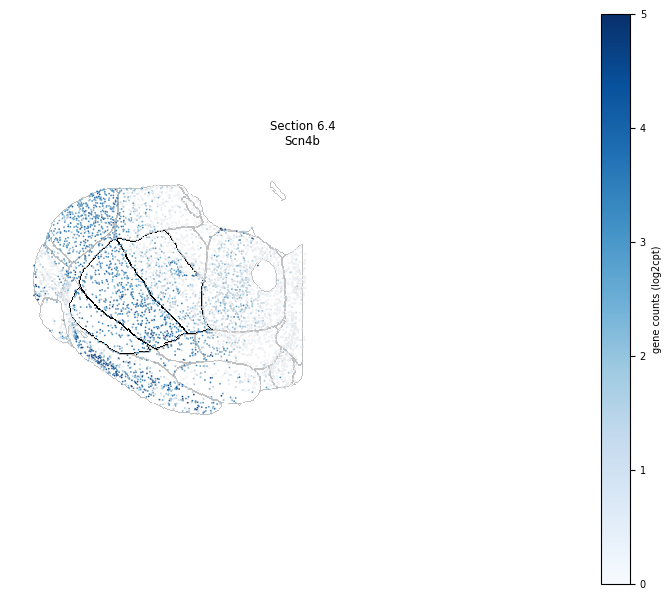

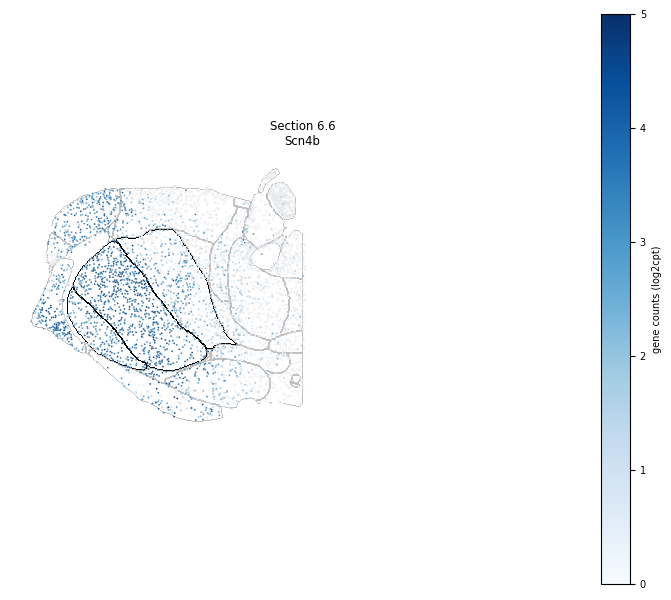

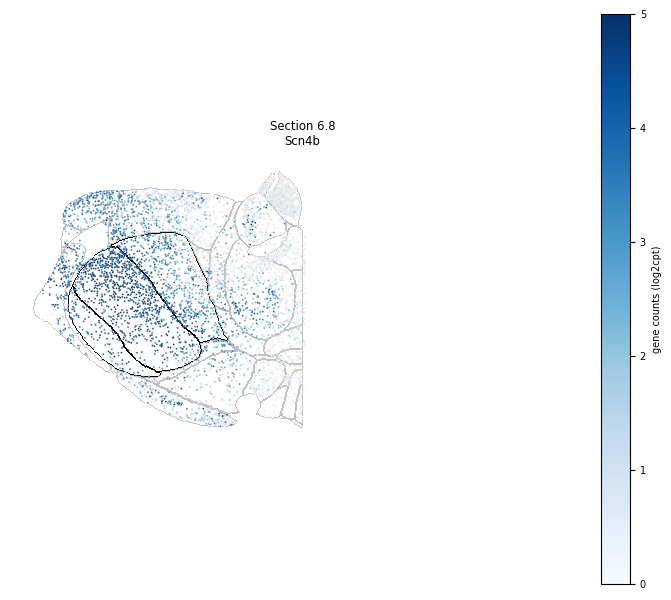

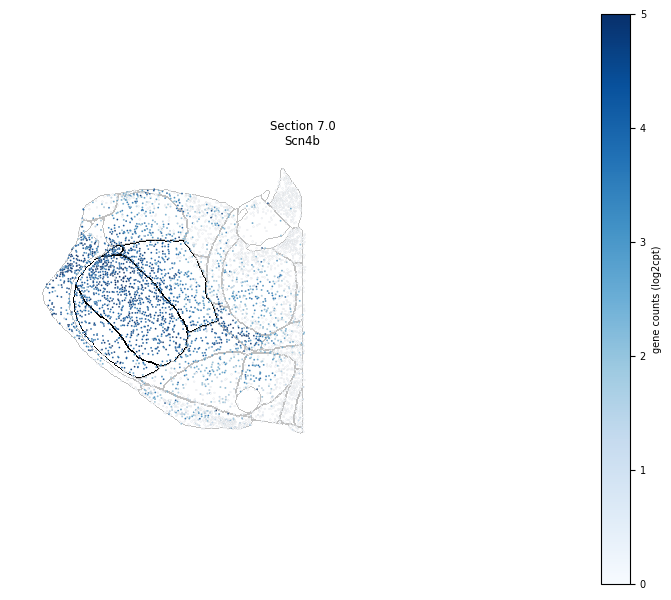

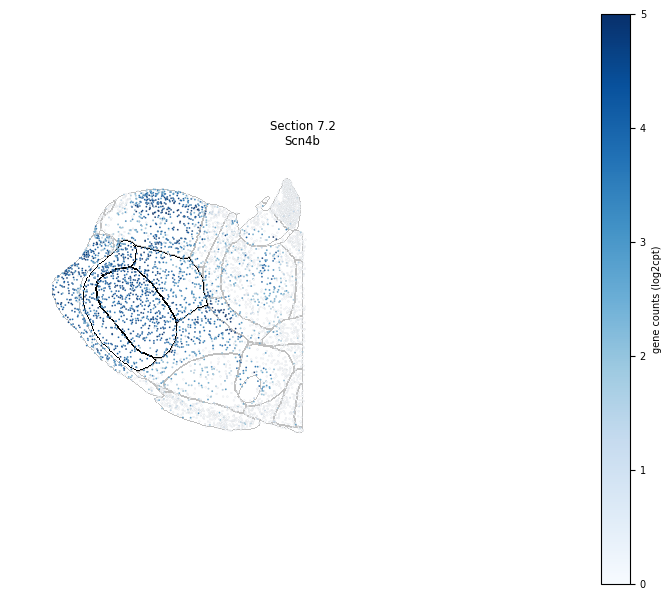

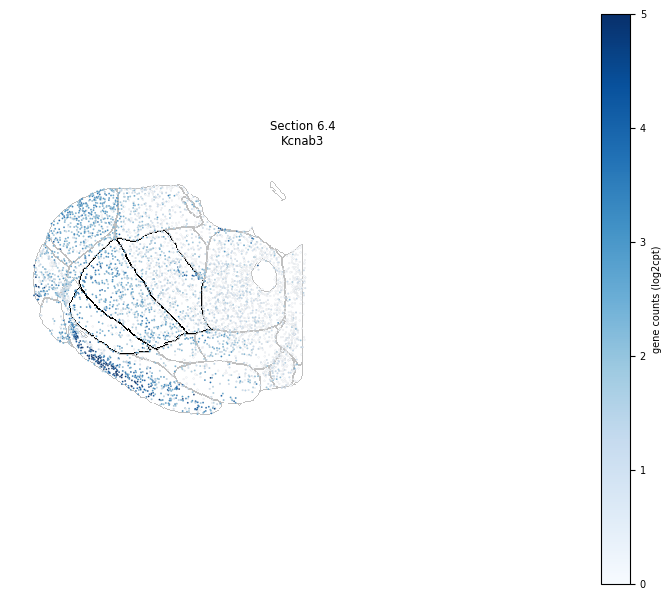

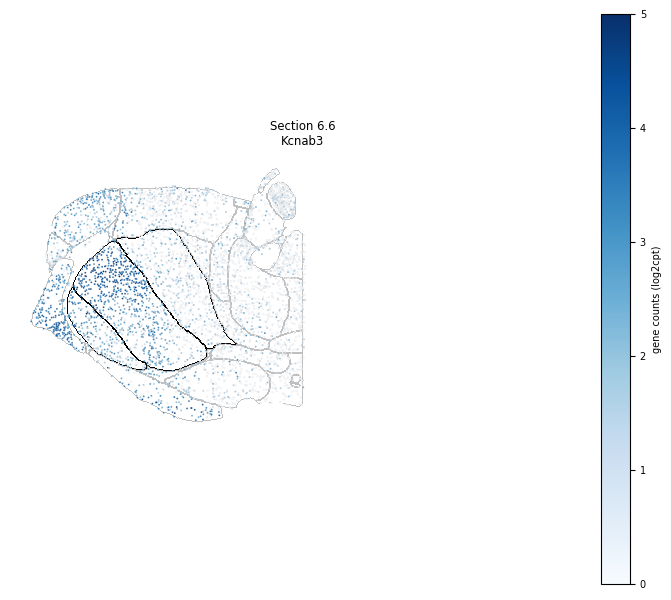

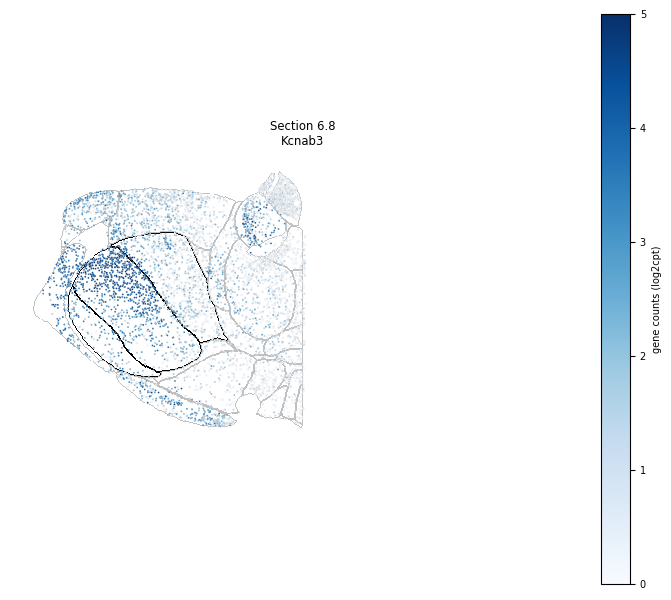

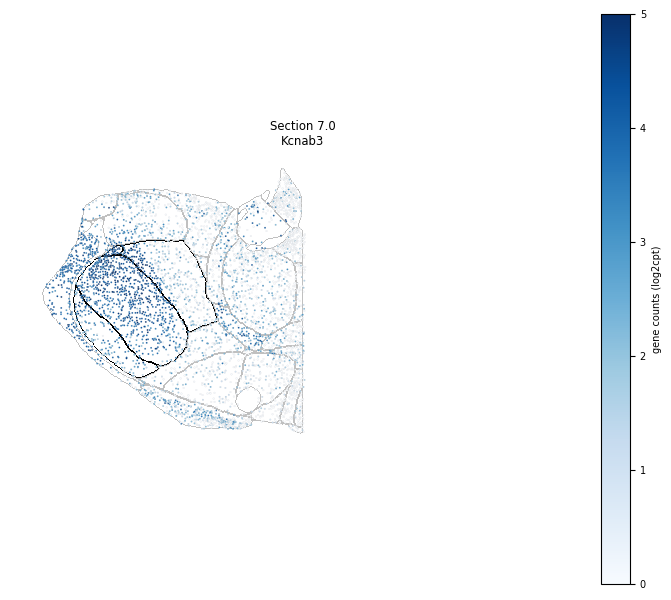

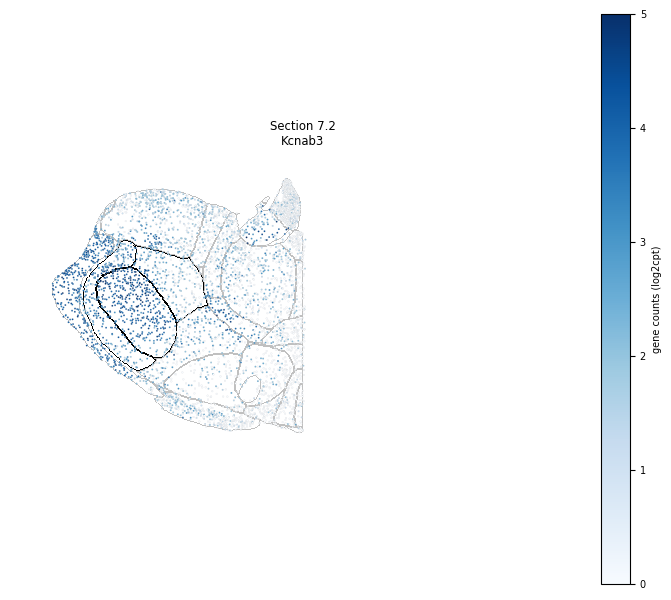

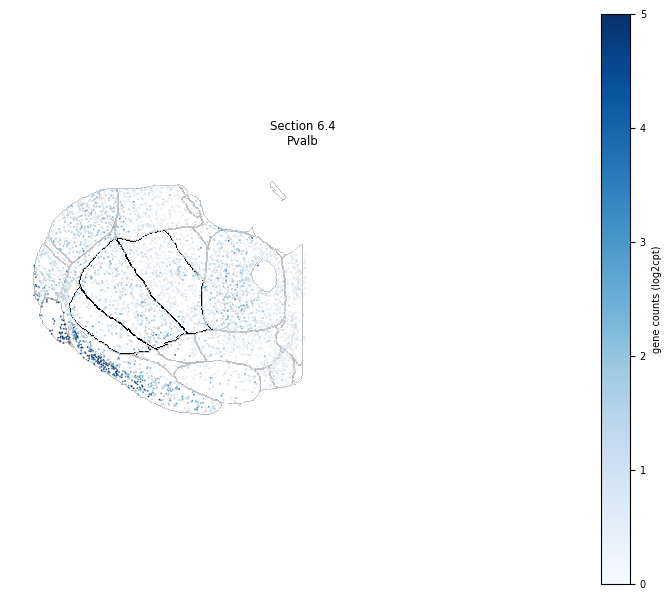

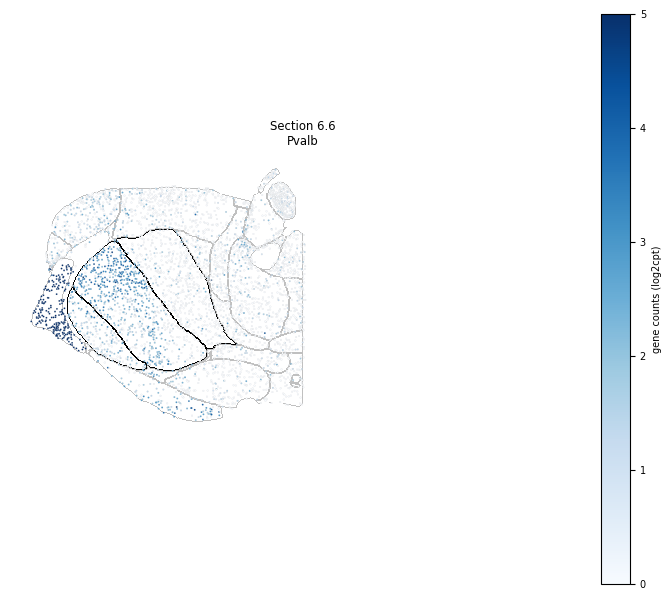

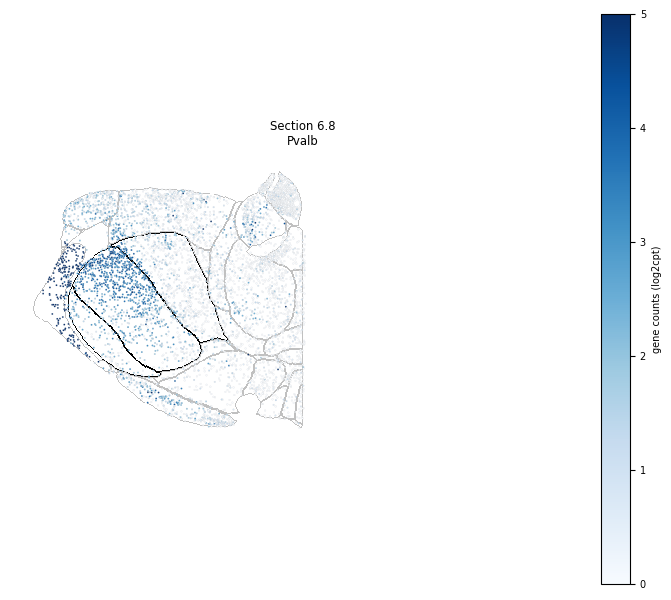

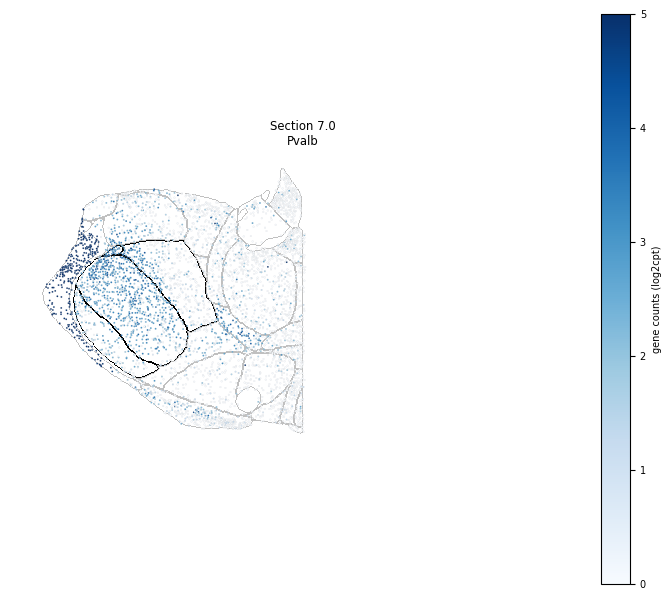

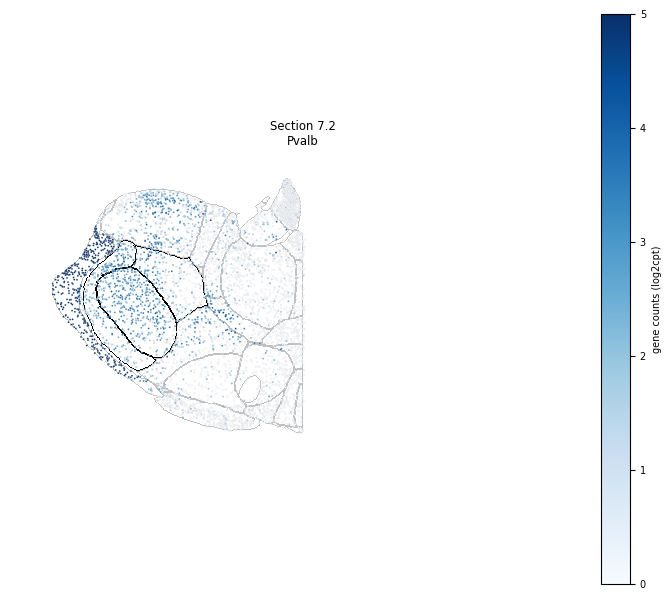

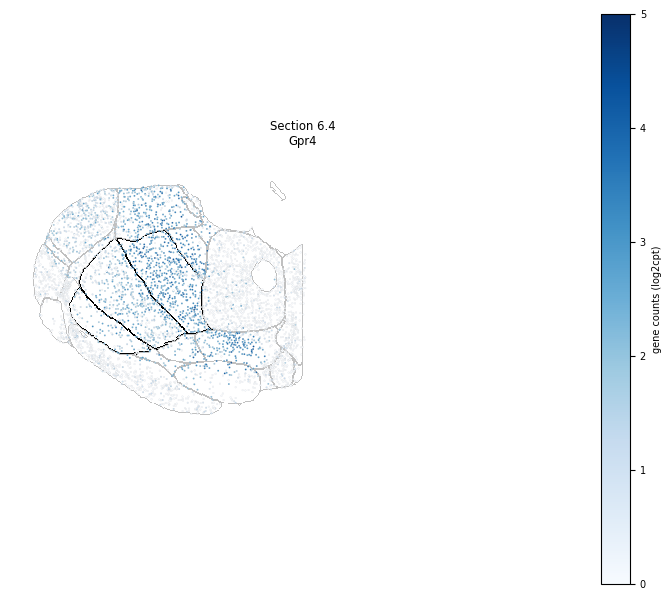

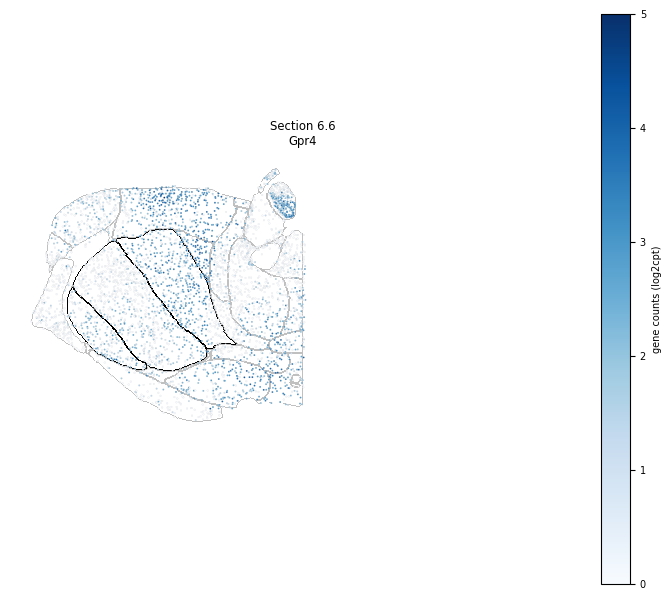

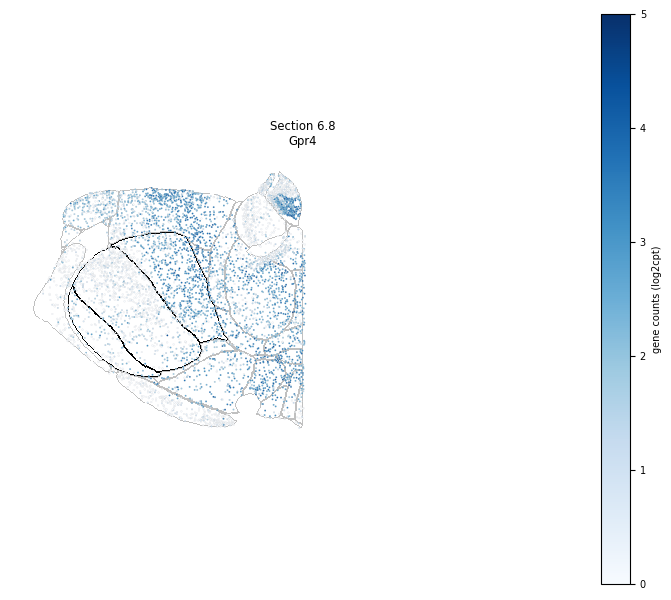

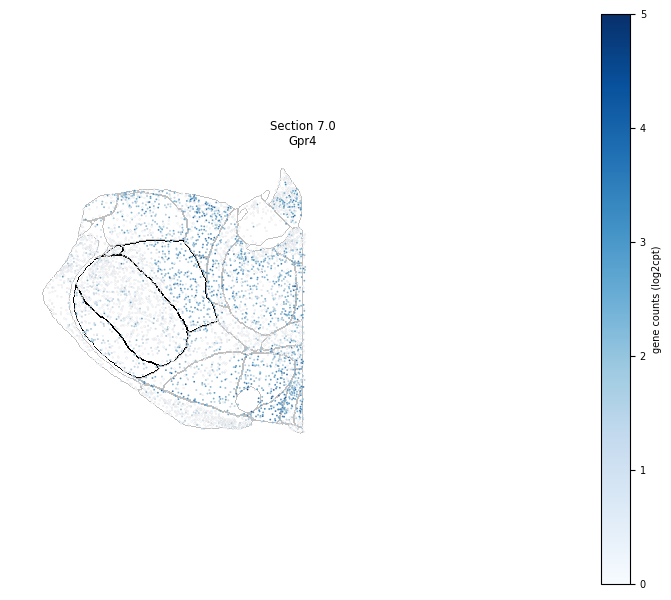

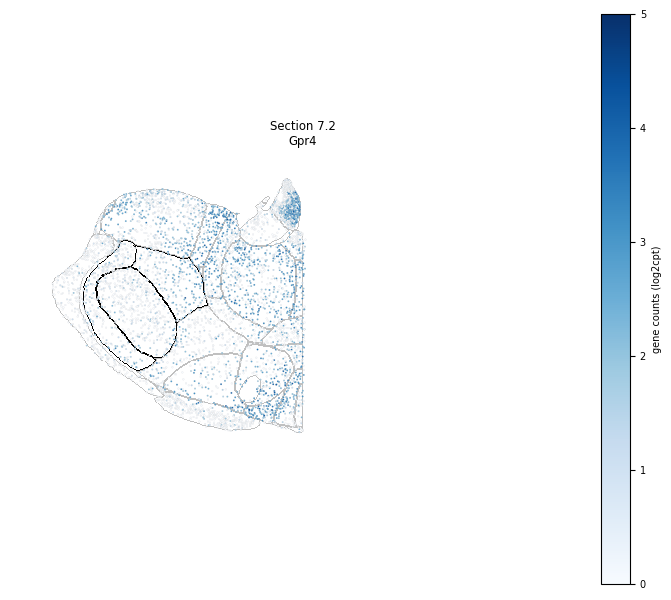

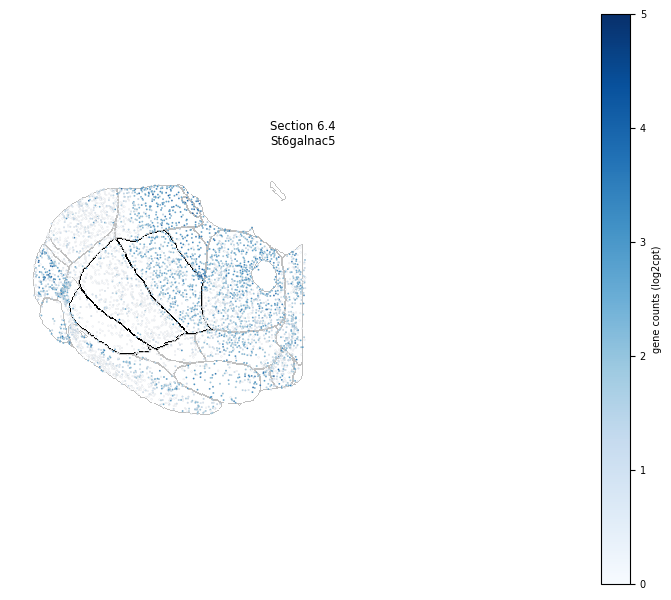

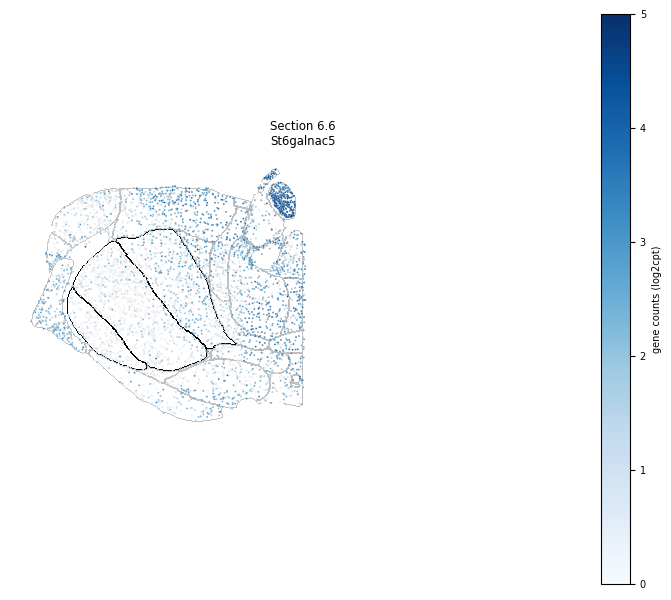

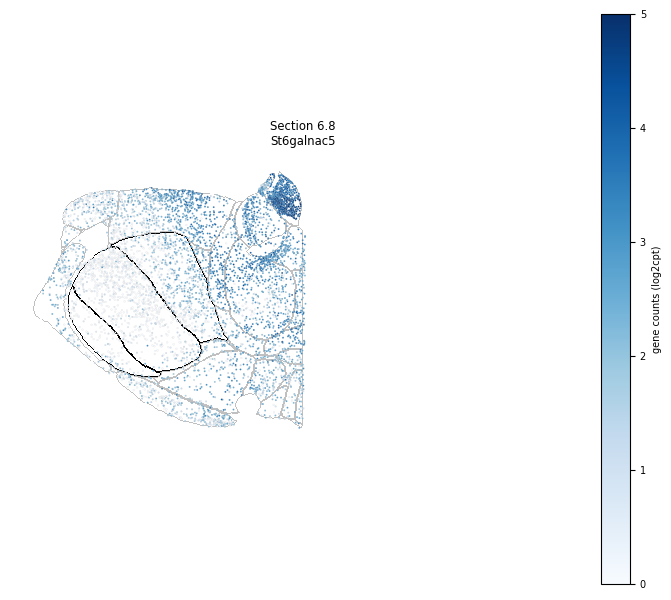

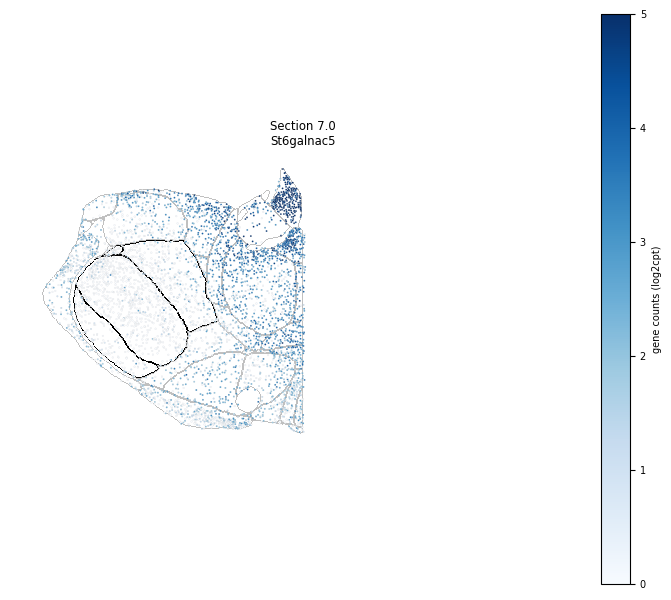

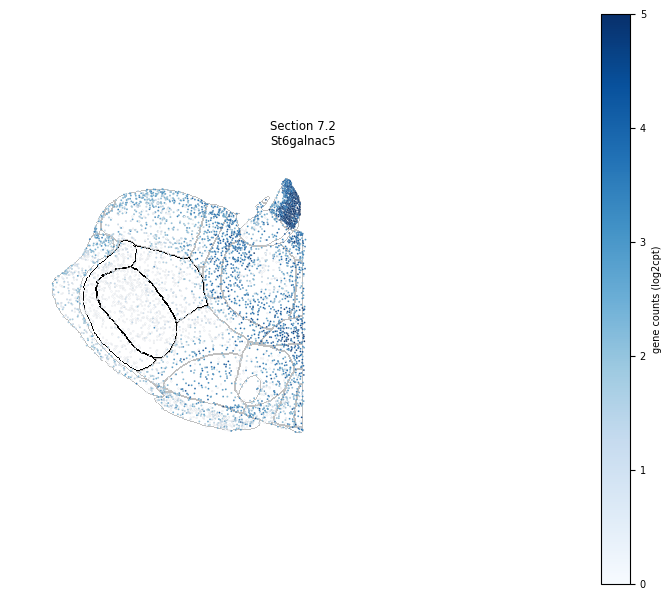

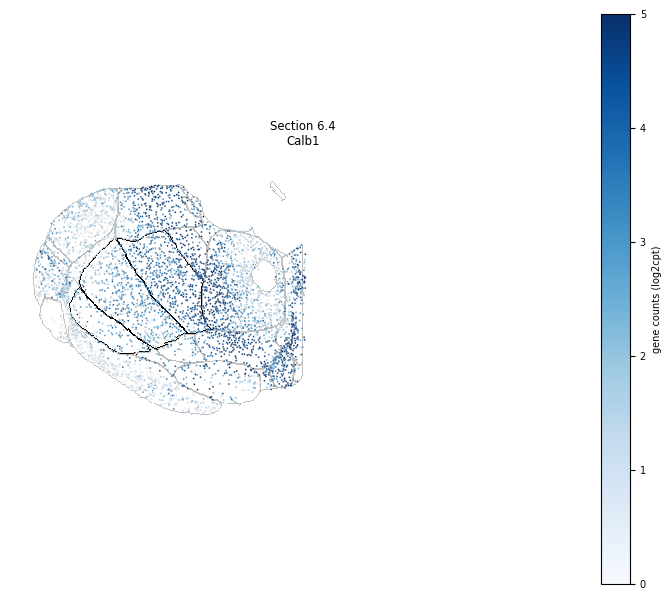

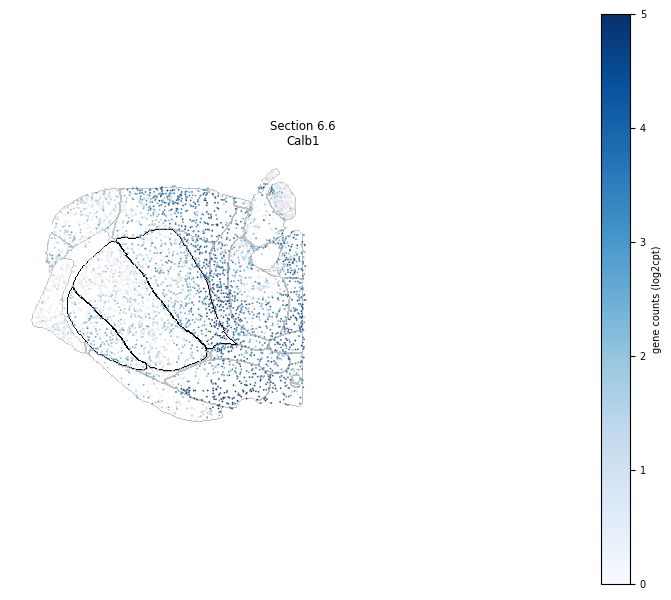

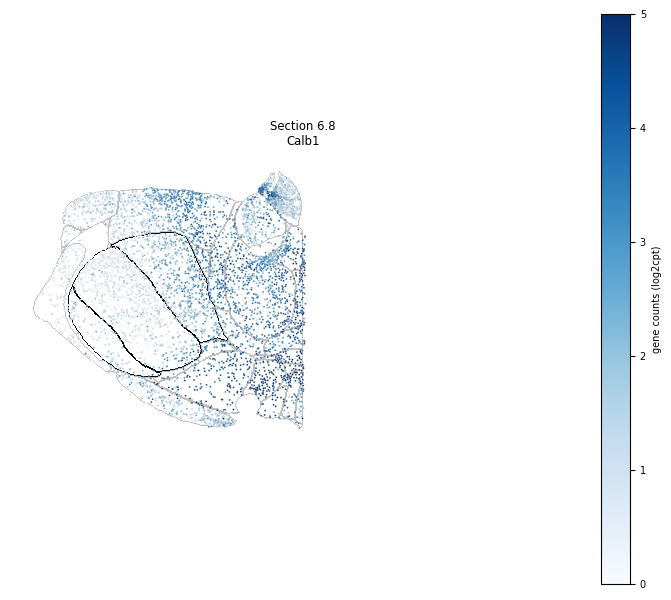

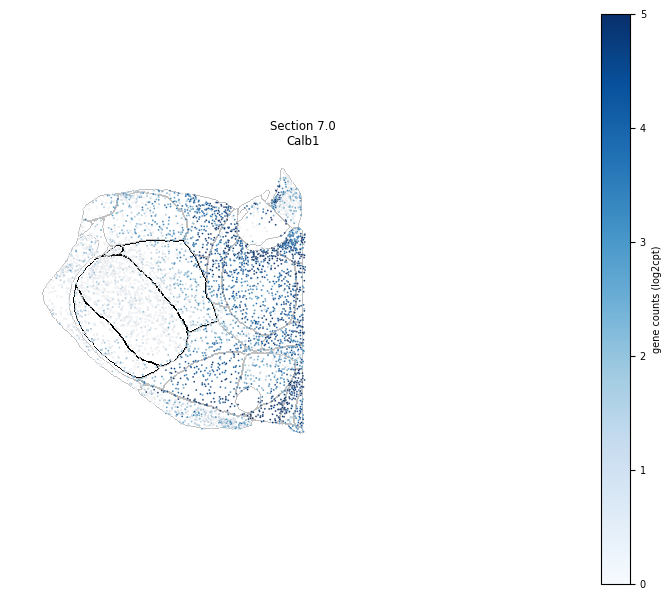

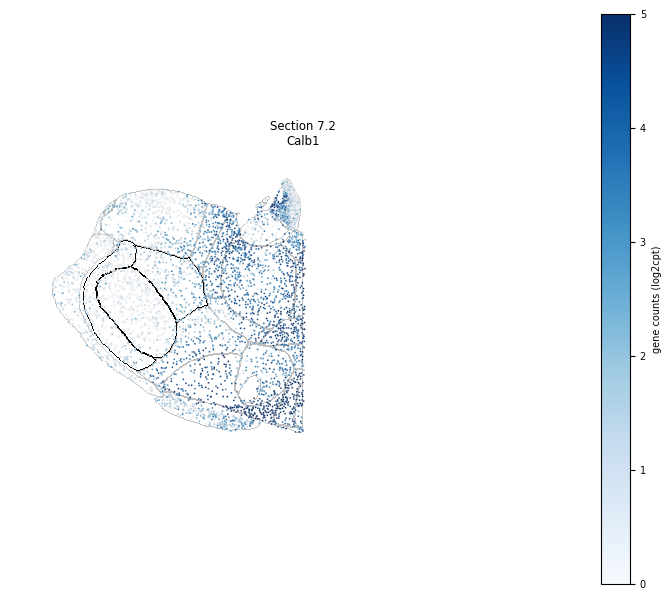

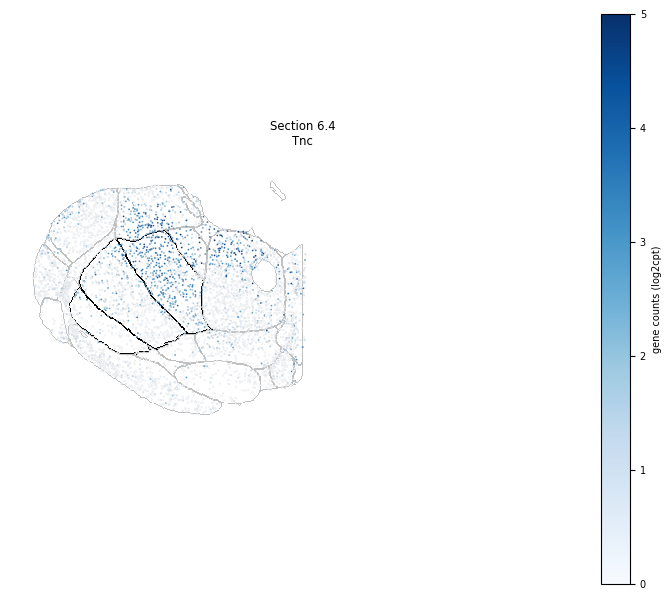

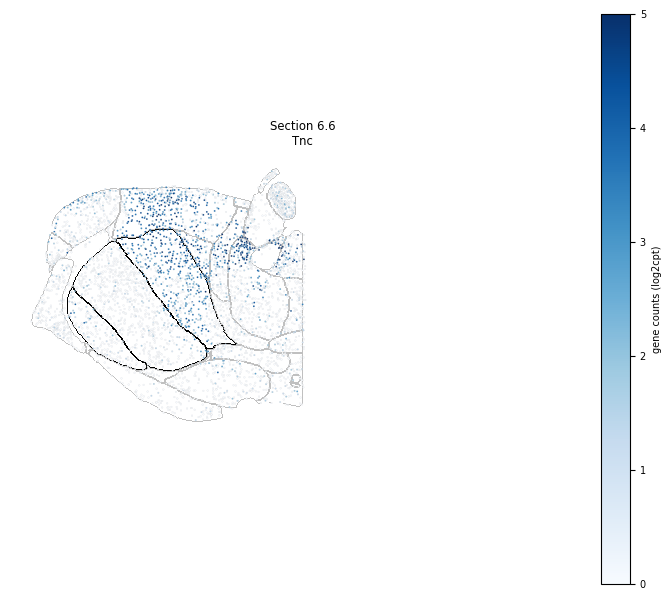

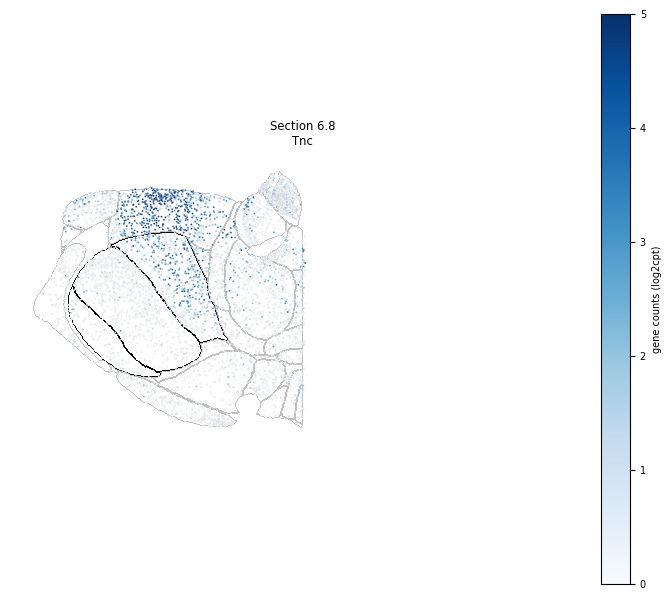

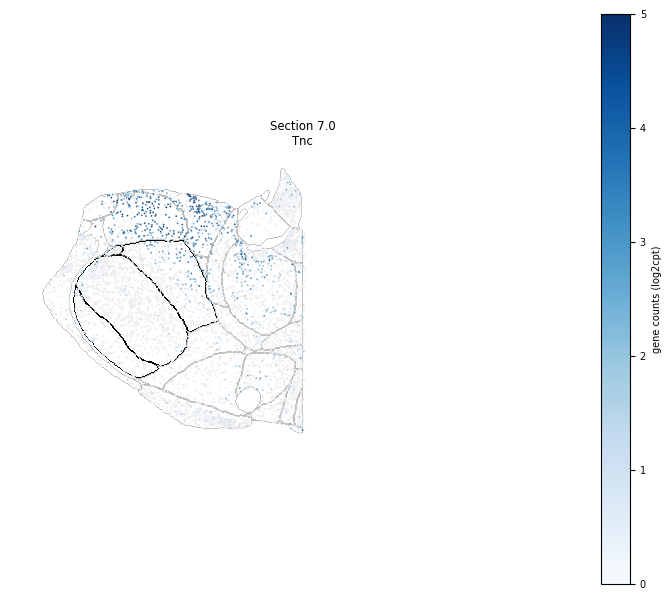

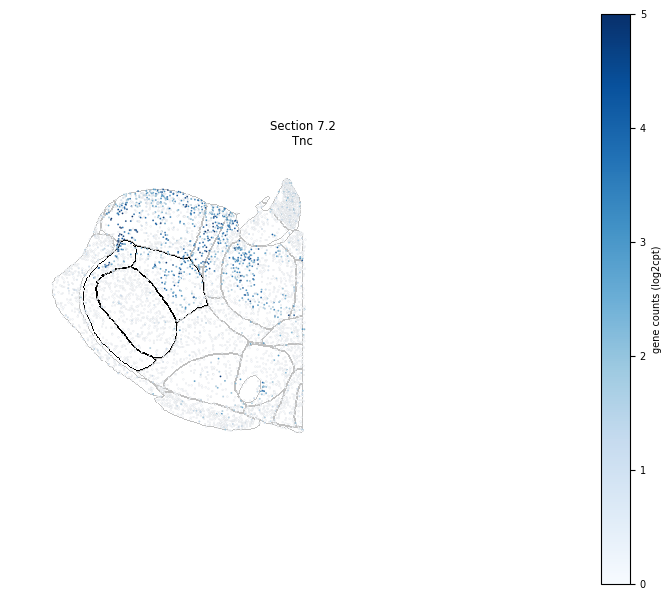

In [24]:
# show outlines for all the ATN
nuclei_to_highlight = nuclei_somatosensory
sections_to_plot = sections_somatosensory
taxonomy_level = 'supertype'

kwargs_ATN_expr = dict(
    boundary_img=ccf_boundaries_left,
    section_col=section_col,
    x_col=x_col,
    y_col=y_col,
    cmap='Blues',
    cb_vmin_vmax=(0,5),
    point_size=1.5,
    edge_color='silver',
    edgecolors='silver',
    linewidths=0.1,
    # figsize=(1.8,1.8),
    figsize=(8,8),
    )

# AD DEGs
for gene in deg_list_somatosensory_st_manual:
    fig = cplots.plot_expression_ccf(adata_th_left, 
                               gene, 
                               ccf_images_left,
                               sections=sections_to_plot,
                               highlight=nuclei_to_highlight,
                            #    zoom_to_highlighted=True,
                               **kwargs_ATN_expr)
    for j, sec in enumerate(sections_to_plot):
        fig[j].savefig(f'{results_dir}/degs_somatosensory_{taxonomy_level}_{gene}_z{sec}.pdf',
                    transparent=True, bbox_inches='tight', dpi=1200)
        fig[j].savefig(f'{results_dir}/degs_somatosensory_{taxonomy_level}_{gene}_z{sec}.png',
                    transparent=True, bbox_inches='tight', dpi=1200)

## Fig. X? | Somatosensory clusters

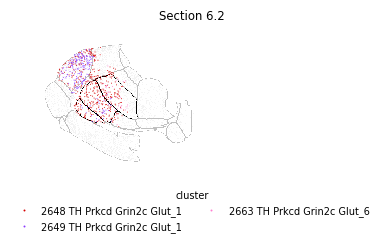

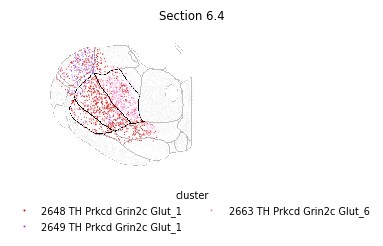

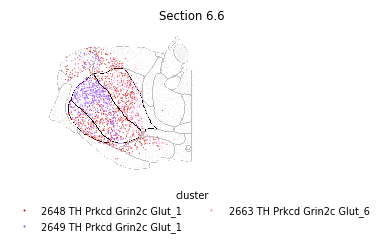

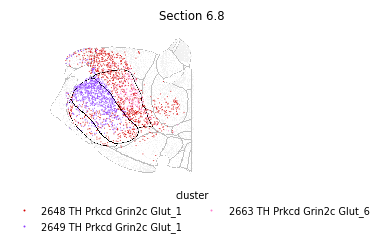

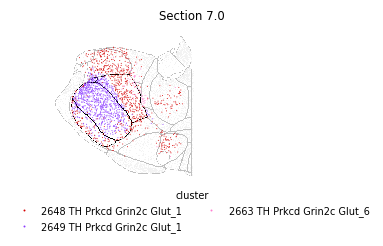

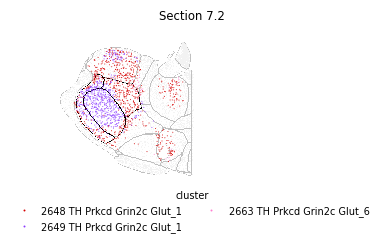

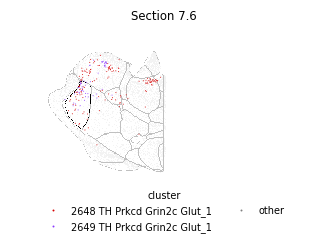

In [19]:
# set kwargs fpr annotated cluster plots
kwargs_cluster_annotations = dict(
    section_col=z_col,
    x_col=x_col,
    y_col=y_col,
    point_size=0.5,
    figsize=(4, 2),
    face_palette=None,
    edge_color='silver'
    )

# get the cluster annotations for the nucleus of interest
sections_to_plot = sections_somatosensory
nuclei_highlight = nuclei_somatosensory
taxonomy_level = 'cluster'
obs_annot_clust_left = abc.get_obs_from_annotations(nuclei_somatosensory, 
                                                    obs_th_left, 
                                                    taxonomy_level=taxonomy_level,
                                                    include_shared_clusters=True)
obs_annot_clust = abc.get_obs_from_annotations(nuclei_somatosensory, 
                                                obs_th, 
                                                taxonomy_level=taxonomy_level,
                                                include_shared_clusters=True)

plt.rcParams.update({'font.size': 7})
figs_annot = cplots.plot_ccf_overlay(obs_annot_clust_left, # obs_annot_clust_left
                                    ccf_images_left,
                                    boundary_img=ccf_boundaries_left, #_left,
                                    bg_cells=obs_th_left, #obs_th_left, 
                                    ccf_highlight=nuclei_highlight,
                                    point_hue=taxonomy_level, 
                                    sections=sections_to_plot,
                                    point_palette=abc_palettes[taxonomy_level],
                                    legend='cells',
                                    **kwargs_cluster_annotations)
for i, sec in enumerate(sections_to_plot):
    figs_annot[i].savefig(f'{results_dir}/figX_{taxonomy_level}_annotations_z{sec}_somatosensory.pdf', 
                          transparent=True, bbox_inches='tight')
    figs_annot[i].savefig(f'{results_dir}/figX_{taxonomy_level}_annotations_z{sec}_somatosensory.png', 
                          transparent=True, bbox_inches='tight', dpi=1200)

In [20]:
cluster_somat_clusters = [
    '2648 TH Prkcd Grin2c Glut_1', # VPL/PO
    '2649 TH Prkcd Grin2c Glut_1', # VPM
    '2663 TH Prkcd Grin2c Glut_6', #PO/Eth
]

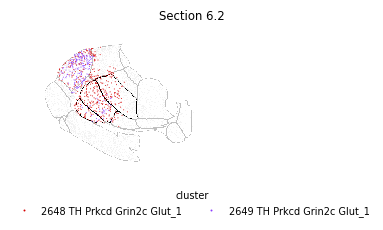

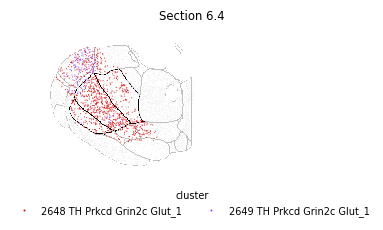

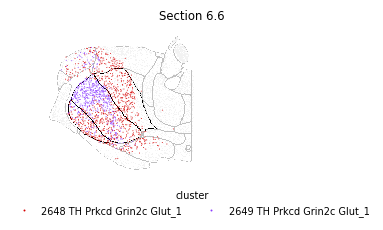

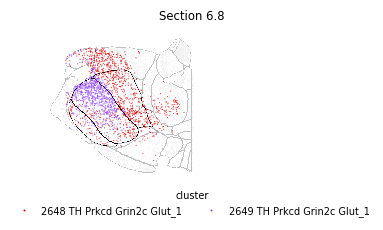

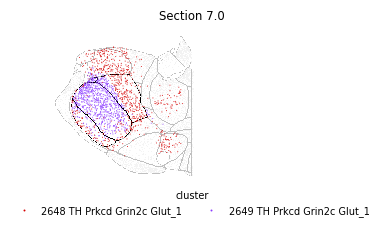

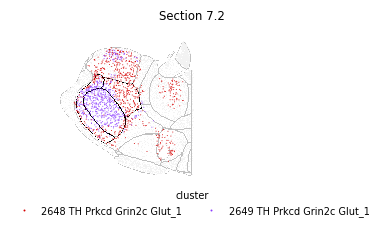

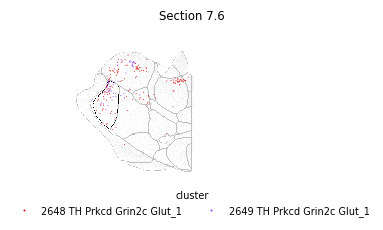

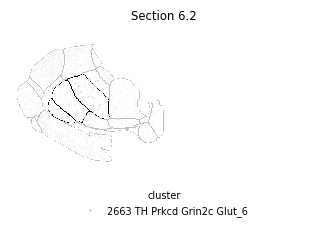

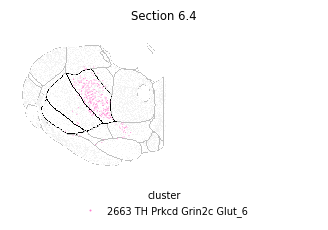

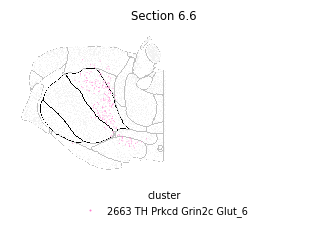

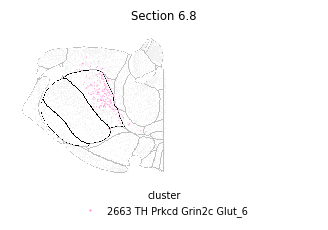

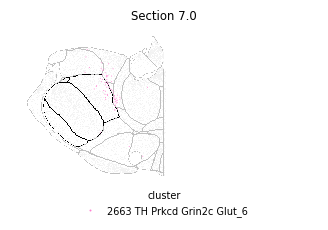

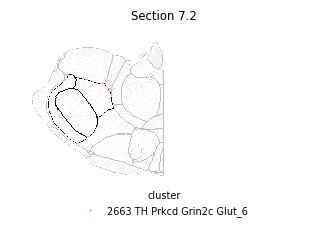

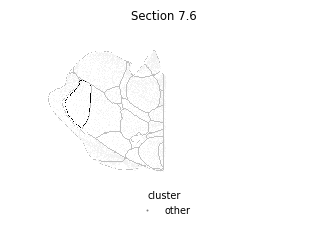

In [22]:
obs_annot_clust_left_st0654 = obs_annot_clust_left[obs_annot_clust_left['cluster'].isin(cluster_somat_clusters[:2])]
obs_annot_clust_left_st0659 = obs_annot_clust_left[obs_annot_clust_left['cluster'].isin([cluster_somat_clusters[2]])]

# Plot the clusters for supertype 654
figs_annot = cplots.plot_ccf_overlay(obs_annot_clust_left_st0654,
                                    ccf_images_left,
                                    boundary_img=ccf_boundaries_left,
                                    bg_cells=obs_th_left,
                                    ccf_highlight=nuclei_highlight,
                                    point_hue=taxonomy_level, 
                                    sections=sections_to_plot,
                                    point_palette=abc_palettes[taxonomy_level],
                                    legend='cells',
                                    **kwargs_cluster_annotations)
for i, sec in enumerate(sections_to_plot):
    figs_annot[i].savefig(f'{results_dir}/figX_{taxonomy_level}_2648_2649_annotations_z{sec}_somatosensory.pdf', 
                          transparent=True, bbox_inches='tight')
    figs_annot[i].savefig(f'{results_dir}/figX_{taxonomy_level}_2648_2649_annotations_z{sec}_somatosensory.png', 
                          transparent=True, bbox_inches='tight', dpi=1200)
    
# Plot the clusters for supertype 659
figs_annot = cplots.plot_ccf_overlay(obs_annot_clust_left_st0659,
                                    ccf_images_left,
                                    boundary_img=ccf_boundaries_left,
                                    bg_cells=obs_th_left,
                                    ccf_highlight=nuclei_highlight,
                                    point_hue=taxonomy_level, 
                                    sections=sections_to_plot,
                                    point_palette=abc_palettes[taxonomy_level],
                                    legend='cells',
                                    **kwargs_cluster_annotations)
for i, sec in enumerate(sections_to_plot):
    figs_annot[i].savefig(f'{results_dir}/figX_{taxonomy_level}_2663_annotations_z{sec}_somatosensory.pdf', 
                          transparent=True, bbox_inches='tight')
    figs_annot[i].savefig(f'{results_dir}/figX_{taxonomy_level}_2663_annotations_z{sec}_somatosensory.png', 
                          transparent=True, bbox_inches='tight', dpi=1200)

In [ ]:
# set kwargs fpr annotated cluster plots
kwargs_cluster_annotations = dict(
    section_col=z_col,
    x_col=x_col,
    y_col=y_col,
    point_size=4,
    figsize=(1.75, 1.5),
    face_palette=None,
    edge_color='silver',
    )

## Fig. 3H | Dotplot of differentially expressed genes (DEGs) in the 7 ATN clusters

In [16]:
# # manual medial-to-lateral cluster ordering for dotplots
# clusters_med_to_lat_ATN = [
#     '2613 AD Serpinb7 Glut_1',
#     '2614 AD Serpinb7 Glut_1',
#     '2615 AV Col27a1 Glut_1',
#     '2616 AV Col27a1 Glut_1',
#     '2674 TH Prkcd Grin2c Glut_9',
#     '2676 TH Prkcd Grin2c Glut_9',
#     '2675 TH Prkcd Grin2c Glut_9',
# ]

# # reorder by manual medial-to-lateral ordering
# adata_annot.obs.loc[:,'cluster'] = adata_annot.obs.loc[:,'cluster'].cat.reorder_categories(clusters_med_to_lat_ATN, ordered=True)
# adata_annot.obs.loc[:,'cluster'].cat.categories

In [17]:
cluster_somat_clusters = [
    '2648 TH Prkcd Grin2c Glut_1', 
    '2649 TH Prkcd Grin2c Glut_1',
    '2663 TH Prkcd Grin2c Glut_6',
]

### Exploratory dotplots for ATN cluster DEGs (5 genes per neighboring cluster pair)

In [18]:
# Helper function to get the top DEGs for a given cluster
def get_rank_genes_list(adata, 
                        groupby='cluster', 
                        group='', 
                        reference='rest', 
                        n_genes=5):
    # find DEGs
    sc.tl.rank_genes_groups(adata, 
                            groupby="cluster", 
                            groups=[group],
                            reference=reference, 
                            n_genes=n_genes, 
                            method="wilcoxon")
    # get DEGs
    deg_list = sc.get.rank_genes_groups_df(adata, group=group).names.to_list()
    
    return deg_list

def create_var_group_positions(n_genes, deg_list):
    total_genes = len(deg_list)
    var_group_positions = []
    for i in range(0, total_genes, n_genes):
        start = i
        end = min(i + n_genes - 1, total_genes - 1)
        var_group_positions.append([start, end])
    return var_group_positions

['Rasgrp1', 'Tnnt1', 'Shisa6', 'Slc17a7', 'Pcp4l1']
['Rasgrp1', 'Tnnt1', 'Shisa6', 'Slc17a7', 'Pcp4l1', 'Tnnt1', 'Scn4b', 'Rgs4', 'Kcnab3', 'Lhfp']
['Rasgrp1', 'Tnnt1', 'Shisa6', 'Slc17a7', 'Pcp4l1', 'Tnnt1', 'Scn4b', 'Rgs4', 'Kcnab3', 'Lhfp', 'Ramp3', 'Shisa6', 'Adgrf5', 'Cnih3', 'Gpr4']


/opt/conda/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


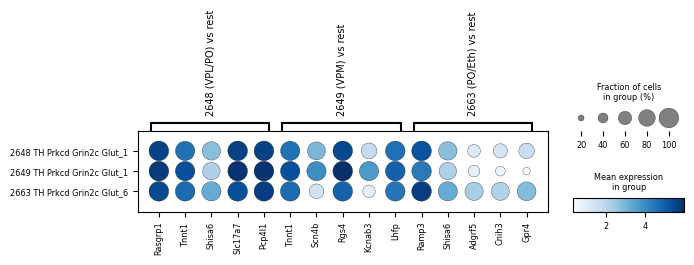

In [20]:
deg_cluster_vs_rest = []
n_genes = 5

# 2648 vs rest
deg_cluster_vs_rest.extend(get_rank_genes_list(adata_th, 
                                               group='2648 TH Prkcd Grin2c Glut_1', 
                                               reference='rest',
                                               n_genes=n_genes))
print(deg_cluster_vs_rest)

# 2649 vs rest
deg_cluster_vs_rest.extend(get_rank_genes_list(adata_th, 
                                               group='2649 TH Prkcd Grin2c Glut_1', 
                                               reference='rest',
                                               n_genes=n_genes))
print(deg_cluster_vs_rest)

# 2663 vs rest
deg_cluster_vs_rest.extend(get_rank_genes_list(adata_th, 
                                               group='2663 TH Prkcd Grin2c Glut_6', 
                                               reference='rest',
                                               n_genes=n_genes))
print(deg_cluster_vs_rest)


# manually set gene group labels for dotplot
var_group_labels = [
  '2648 (VPL/PO) vs rest',
  '2649 (VPM) vs rest',
  '2663 (PO/Eth) vs rest',
  ]
var_group_positions = create_var_group_positions(n_genes, deg_cluster_vs_rest)

# dotplot
dotplot_clusters_vs_rest = sc.pl.dotplot(adata_annot,
              deg_cluster_vs_rest, 
              groupby='cluster', 
              dendrogram=False,
              cmap='Blues',
              var_group_positions=var_group_positions,
              var_group_labels=var_group_labels,
              return_fig=True,
              # var_group_rotation=0,
              )
# save
dotplot_clusters_vs_rest.savefig(f'{results_dir}/figX_degs_somatosensory_{taxonomy_level}_vs_rest_dotplot.pdf', 
                          transparent=True, bbox_inches='tight')

['Calb1', 'Gpr4', 'Ramp3', 'Spon1', 'Tcf7l2']
['Calb1', 'Gpr4', 'Ramp3', 'Spon1', 'Tcf7l2', 'Kcnab3', 'Pvalb', 'Scn4b', 'Shroom3', 'Tnnt1']
['Calb1', 'Gpr4', 'Ramp3', 'Spon1', 'Tcf7l2', 'Kcnab3', 'Pvalb', 'Scn4b', 'Shroom3', 'Tnnt1', 'Scn4b', 'Rgs4', 'Rorb', 'Kcnab3', 'Slc17a7']
['Calb1', 'Gpr4', 'Ramp3', 'Spon1', 'Tcf7l2', 'Kcnab3', 'Pvalb', 'Scn4b', 'Shroom3', 'Tnnt1', 'Scn4b', 'Rgs4', 'Rorb', 'Kcnab3', 'Slc17a7', 'St6galnac5', 'Tcf7l2', 'Gpr4', 'Grik1', 'Calb1']
['Calb1', 'Gpr4', 'Ramp3', 'Spon1', 'Tcf7l2', 'Kcnab3', 'Pvalb', 'Scn4b', 'Shroom3', 'Tnnt1', 'Scn4b', 'Rgs4', 'Rorb', 'Kcnab3', 'Slc17a7', 'St6galnac5', 'Tcf7l2', 'Gpr4', 'Grik1', 'Calb1', 'Kcnab3', 'Scn4b', 'Pvalb', 'Rgs4', 'Rorb', 'Calb1', 'Gpr4', 'Tcf7l2', 'Ramp3', 'St6galnac5']


/opt/conda/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


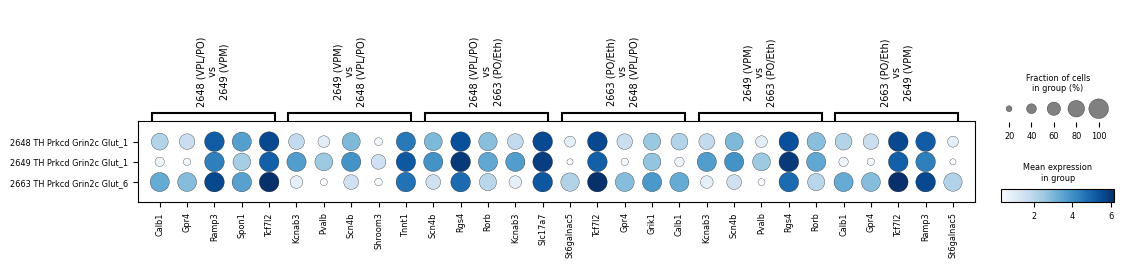

In [21]:
deg_paired_clust_list = []
n_genes = 5

# 2648 vs 2649
deg_paired_clust_list.extend(get_rank_genes_list(adata_annot, 
                                               group='2648 TH Prkcd Grin2c Glut_1', 
                                               reference='2649 TH Prkcd Grin2c Glut_1',
                                               n_genes=n_genes))
print(deg_paired_clust_list)
# sc.pl.rank_genes_groups(adata_annot, group=cluster_list_annot[0])
deg_paired_clust_list.extend(get_rank_genes_list(adata_annot, 
                                               group='2649 TH Prkcd Grin2c Glut_1', 
                                               reference='2648 TH Prkcd Grin2c Glut_1',
                                               n_genes=n_genes))
print(deg_paired_clust_list)

# 2648 vs 2663
deg_paired_clust_list.extend(get_rank_genes_list(adata_annot, 
                                               group='2648 TH Prkcd Grin2c Glut_1',
                                               reference='2663 TH Prkcd Grin2c Glut_6',
                                               n_genes=n_genes))
print(deg_paired_clust_list)
deg_paired_clust_list.extend(get_rank_genes_list(adata_annot, 
                                               group='2663 TH Prkcd Grin2c Glut_6',
                                               reference='2648 TH Prkcd Grin2c Glut_1',
                                               n_genes=n_genes))
print(deg_paired_clust_list)

# 2649 vs 2663
deg_paired_clust_list.extend(get_rank_genes_list(adata_annot, 
                                               group='2649 TH Prkcd Grin2c Glut_1', 
                                               reference='2663 TH Prkcd Grin2c Glut_6',
                                               n_genes=n_genes))
deg_paired_clust_list.extend(get_rank_genes_list(adata_annot, 
                                               group='2663 TH Prkcd Grin2c Glut_6', 
                                               reference='2649 TH Prkcd Grin2c Glut_1',
                                               n_genes=n_genes))
print(deg_paired_clust_list)

# set gene group labels for dotplot
var_group_positions = create_var_group_positions(n_genes, deg_paired_clust_list)
var_group_labels = [
  '2648 (VPL/PO)\n vs \n2649 (VPM)',
  '2649 (VPM)\n vs \n2648 (VPL/PO)',
  '2648 (VPL/PO)\n vs \n2663 (PO/Eth)',
  '2663 (PO/Eth)\n vs \n2648 (VPL/PO)',
  '2649 (VPM)\n vs \n2663 (PO/Eth)',
  '2663 (PO/Eth)\n vs \n2649 (VPM)',
]

# dotplot
dotplot_clusters_paired = sc.pl.dotplot(adata_annot,
              deg_paired_clust_list, 
              groupby='cluster', 
              dendrogram=False,
              cmap='Blues',
              var_group_positions=var_group_positions,
              var_group_labels=var_group_labels,
              return_fig=True,
            #   var_group_rotation=0,
              )
# save
dotplot_clusters_paired.savefig(f'{results_dir}/figX_degs_somatosensory_{taxonomy_level}_paired_dotplot.pdf', 
                          transparent=True, bbox_inches='tight')

### Curated dotplot of ATN cluster DEGs for Fig. 3H

In [22]:
marker_genes_manual = [
    # 2648 (VPL/PO)
    'Ramp3', 'Spon1', 'Tcf7l2',
    # 2649 (VPM)  
    'Kcnab3', 'Pvalb', 'Scn4b',
    # 2663 (PO/Eth)           
    'Gpr4', 'Adgrf5', 'Cnih3', #'Calb1', 'St6galnac5',             
]                             

var_group_positions = create_var_group_positions(n_genes=3, deg_list=marker_genes_manual)

var_group_labels = ['2648 (VPL/PO)',
                    '2649 (VPM)',
                    '2663 (PO/Eth)',
                    ]

/opt/conda/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:749: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


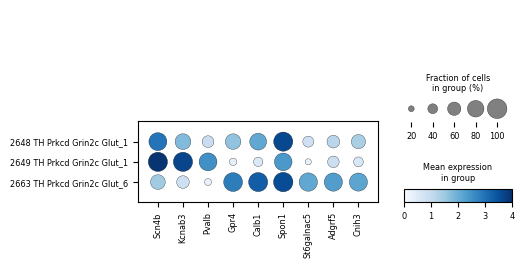

In [33]:
cluster_degs_manual_dotplot = [
    'Scn4b', # 2648 & 2649
    'Kcnab3', 'Pvalb', # 2649
    'Gpr4', 'Calb1', 'Spon1', # 2648 & 2663
    'St6galnac5', 'Adgrf5', 'Cnih3', # 2663
    
]
dotplot_cluster_curated = sc.pl.dotplot(adata_annot,
                            cluster_degs_manual_dotplot,
                            groupby='cluster', 
                            dendrogram=False,
                            cmap='Blues', #cc.cm.blues, cc.cm.CET_CBL3_r
                            vmin=0,
                            vmax=4,
                            # var_group_positions=var_group_positions,
                            # var_group_labels=var_group_labels,
                            # var_group_rotation=90,
                            return_fig=True,
                            )

dotplot_cluster_curated.savefig(f'{results_dir}/figX_degs_somatosensory_{taxonomy_level}_dotplot_curated.pdf',
                    transparent=True, bbox_inches='tight')

In [1]:
# show outlines for all the ATN
nuclei_to_highlight = nuclei_somatosensory
sections_to_plot = sections_somatosensory

kwargs_ATN_expr = dict(
    boundary_img=ccf_boundaries_left,
    section_col=section_col,
    x_col=x_col,
    y_col=y_col,
    cmap='Blues',
    cb_vmin_vmax=(0,5),
    point_size=1.5,
    edge_color='silver',
    edgecolors='silver',
    linewidths=0.1,
    # figsize=(1.8,1.8),
    figsize=(8,8),
    )

# 2663 manual genes
marker_genes_manual = ['Scn4b']#['Gpr4', 'Adgrf5', 'Cnih3', 'Calb1', 'St6galnac5']
for i, gene in enumerate(marker_genes_manual):
    if i==0:
        print('2648 (VPL/PO) genes')
    elif i==3:
        print('2649 (VPM) genes')
    elif i==6:
        print('2663 (PO/Eth) genes')
        
    fig = cplots.plot_expression_ccf(adata_th_left, 
                               gene, 
                               ccf_images_left,
                               sections=sections_to_plot,
                               highlight=nuclei_to_highlight,
                            #    zoom_to_highlighted=True,
                               **kwargs_ATN_expr)
    for j, sec in enumerate(sections_to_plot):
        fig[j].savefig(f'{results_dir}/figX_degs_somatosensory_{taxonomy_level}_{gene}_z{sec}.pdf',
                       transparent=True, bbox_inches='tight', dpi=1200)
        fig[j].savefig(f'{results_dir}/figX_degs_somatosensory_{taxonomy_level}_{gene}_z{sec}.png',
                       transparent=True, bbox_inches='tight', dpi=1200)

NameError: name 'nuclei_somatosensory' is not defined